#### Lecture fichier ODS

On doit lire le fichier ods dans un premier temps.
C'est lui qui contient les données.

In [205]:
from pandas_ods_reader import read_ods
import numpy as np

In [206]:
df = read_ods('natacha-13092026.ods')
df

,Date,Heure,Repas,Aliments,Médicaments,Douleur,occasion,Commentaires,unnamed.1
0,2026-09-04,PT07H15M00S,Petit-déjeuner,Yaourt,NaN,0.0,NaN,NaN,NaN
1,2026-09-04,PT11H00M00S,Déjeuner,riz;thon;oeuf;mayonnaise,NaN,0.0,NaN,NaN,NaN
2,2026-09-04,PT14H10M00S,NaN,NaN,NaN,6.0,NaN,NaN,NaN
3,2026-09-04,PT14H31M00S,NaN,NaN,NaN,3.0,NaN,NaN,NaN
4,2026-09-04,PT19H00M00S,Diner,sushi,NaN,1.0,6 mois,NaN,NaN
5,2026-09-05,PT13H26M00S,Déjeuner,pain;poulet;crudité; gateau;chocolat; fuze tea,oui,1.0,anniversaire,NaN,NaN
6,2026-09-05,PT16H00M00S,NaN,NaN,oui,1.0,NaN,NaN,NaN
7,2026-09-05,PT21H15M00S,Dîner,patate; fromage; jambon ; gâteau;chocolat,oui,1.0,anniversaire,NaN,NaN
8,2026-09-06,PT12H31M00S,Déjeuner,saucisse; epinard; crème; riz,oui,3.0,NaN,NaN,NaN
9,2026-09-06,PT13H56M00S,NaN,NaN,oui,6.0,NaN,NaN,NaN


je veux remplacer les deux colonnes **Dates** et **Heures** par une seule, un nombre flottant dont la valeur 0 est le début de notre expérience qui représente ensuite les heures passées depuis cet instant initial.

In [207]:
import pandas as pd

# 2. Conversion de la colonne date (colonne 0) en format datetime
dates = pd.to_datetime(df.iloc[:, 0])

# 3. Conversion de la colonne heure ISO 8601 (colonne 1) en durée
heures = pd.to_timedelta(df.iloc[:, 1])

# 4. Fusionner la date et l'heure
datetimes = dates + heures

# 5. Nombre d'heures écoulées depuis le premier relevé.
#    On passe par total_seconds() plutôt que par astype('int64'), qui dépend
#    de l'unité interne du datetime64 (ici des microsecondes, pas des nanosecondes).
timestamp_relatif = (datetimes - datetimes.iloc[0]).dt.total_seconds() / 3600
df.insert(0, 'timestamp', timestamp_relatif)

# 4. Supprimer les anciennes colonnes date et heure (qui ont glissé aux index 1 et 2)
df_final = df.drop(columns=df.columns[[1, 2]])
df_final

,timestamp,Repas,Aliments,Médicaments,Douleur,occasion,Commentaires,unnamed.1
0,0.000000,Petit-déjeuner,Yaourt,NaN,0.0,NaN,NaN,NaN
1,3.750000,Déjeuner,riz;thon;oeuf;mayonnaise,NaN,0.0,NaN,NaN,NaN
2,6.916667,NaN,NaN,NaN,6.0,NaN,NaN,NaN
3,7.266667,NaN,NaN,NaN,3.0,NaN,NaN,NaN
4,11.750000,Diner,sushi,NaN,1.0,6 mois,NaN,NaN
5,30.183333,Déjeuner,pain;poulet;crudité; gateau;chocolat; fuze tea,oui,1.0,anniversaire,NaN,NaN
6,32.750000,NaN,NaN,oui,1.0,NaN,NaN,NaN
7,38.000000,Dîner,patate; fromage; jambon ; gâteau;chocolat,oui,1.0,anniversaire,NaN,NaN
8,53.266667,Déjeuner,saucisse; epinard; crème; riz,oui,3.0,NaN,NaN,NaN
9,54.683333,NaN,NaN,oui,6.0,NaN,NaN,NaN


In [208]:
import unicodedata

def normalize(name):                                                            
    """ Normalize a food name to a canonical form: lowercase, no accents, unified separators  .                                                                                           
                                                                                  
    Examples:                                                                   
        >>> normalize("Chocolate bread")                                        
        'chocolate_bread'                                                       
        >>> normalize("Crème brûlée")                                           
        'creme_brulee'                                                          
        >>> normalize("Fruit salad - fresh")                                    
        'fruit_salad_fresh'                                                     
                                                                                  
    Args:                                                                       
        name (str): The food name to normalize.                                 
                                                                                
    Returns:                                                                    
        str: The normalized food name.                                          
    """                                                                         
    name = unicodedata.normalize("NFKD", name.strip().lower())                  
    name = "".join(c for c in name if not unicodedata.combining(c))             
    return "_".join(name.replace("-", " ").replace("_", " ").split())           
                  
def suspicious_names(names, max_distance=1):                                  
    """Report food or medication names that are nearly identical (typos)."""    
    suspects = []                                                               
    for i, a in enumerate(names):                                               
        for b in names[i + 1:]:                                                 
            if abs(len(a) - len(b)) > max_distance or a[0] != b[0]:             
                continue                                                        
            if _distance(a, b) <= max_distance:                                 
                suspects.append(f"'{a}' and '{b}': the same food?")
    return suspects


def _distance(a, b):                                                            
    """ Levenshtein distance (edit distance) between two strings.               
                                                                                
    Args:                                                                       
        a (str): first string                                                   
        b (str): second string                                                  
                                                                                
    Returns:                                                                    
        int: Levenshtein distance between a and b                               
    """                                                                         
    prev = list(range(len(b) + 1))                                              
    for i, ca in enumerate(a, 1):                                               
        current = [i]                                                                       
        for j, cb in enumerate(b, 1):                                           
            current.append(min(prev[j] + 1, current[j - 1] + 1, prev[j - 1] + (ca != cb)))
        prev = current                                                          
    return prev[-1]                                                             

On récupère les aliments, on simplifie leur écriture, on retire les doublons :

In [209]:
foods = (df_final['Aliments'].dropna()
            .str.split(';')
            .explode().str.strip())

foods = sorted(set(normalize(a) for a in foods))

On vérifie qu'il n'y a pas des noms proches qui signifieraient la même chose :

In [210]:
suspicious_foods = suspicious_names(foods)

In [211]:
if len(suspicious_foods) > 0:
    print("La liste des suspicious_meals devrait être vide, il faut vérifier le fichier ods")
else:
    print("Il ne semble pas avoir de mauvais doublons")

Il ne semble pas avoir de mauvais doublons


In [212]:
foods

['avocat',
 'boeuf',
 'bouillon',
 'chocolat',
 'creme',
 'crudite',
 'epinard',
 'fromage',
 'fromage_frais',
 'fuze_tea',
 'gateau',
 'gnocchi',
 'jambon',
 'lardons',
 'mayonnaise',
 'oeuf',
 'pain',
 'patate',
 'pates',
 'petits_pois',
 'pizza',
 'poivrons',
 'poulet',
 'riz',
 'sauce_pesto',
 'sauce_tomate',
 'saucisse',
 'sushi',
 'thon',
 'truite',
 'yaourt']

On crée des fonctions références, que l'on appelle *noyaux*. On en crée 7 qui représentent l'apparition de la douleur à partir d'un certain temps. Le décalage entre la prise de l'aliment et le centre de la bosse de la fonction est `LAG_CENTERS`. Une bosse proche de l'aliment est plus étroite qu'une bosse qui arrive plus tardivement. La largeur est donnée par `LAG_WIDTHS`.
Une autre info importante, on considère qu'un aliment mangé ne déclenche pas de douleur avant `MIN_DELAY` heures. Par défaut, c'est un quart d'heure.

In [213]:
LAG_CENTERS = np.array([2.0, 5.0, 9.0, 15.0, 24.0, 40.0, 60.0])                 
LAG_WIDTHS = np.array([3.0, 4.0, 5.0, 8.0, 12.0, 18.0, 24.0])                   
MIN_DELAY = 0.25          # A meal never acts on a simultaneous pain            
MAX_SPAN = float(LAG_CENTERS[-1] + LAG_WIDTHS[-1])  

Construisons les fonctions noyaux.

La fonction suivante crée une matrice dont chaque colonne correspond à un noyau d'élévation cosinus centré sur un décalage spécifique. Autrement dit, chaque colonne représente une fonction nulle presque partout sauf autour du centre de décalage où elle prend des valeurs entre 0 et 1. La fonction ressemble à un dome (cos sur l'intervalle $[-\pi, \pi]$).


In [214]:
def kernels_weights(delays):                                                    
    # Conversion of delays to a float array and transposition in column.        
    d = np.asarray(delays, dtype=float)[:, None]                                
                                                                                 
    # Computation of the dome functions for each delay. These functions are named 'weights'.
    u = (d - LAG_CENTERS[None, :]) / LAG_WIDTHS[None, :]                        
    w = 0.5 * (1.0 + np.cos(np.pi * u))                                         
    w[np.abs(u) >= 1.0] = 0.0                                                   
    w[(d < MIN_DELAY).ravel(), :] = 0.0                                         
    return w



prenons un intervalle de temps $[0;100]$ et traçons le résultat d'un appel à cette fonction.

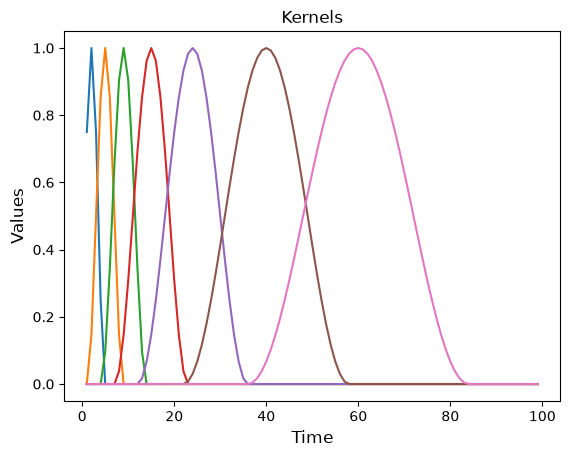

In [215]:
import matplotlib.pyplot as pyplot

pyplot.xlabel('Time', fontsize=12)
pyplot.ylabel('Values', fontsize=12)

pyplot.title('Kernels')

w = kernels_weights(range(1,100))
pyplot.plot(range(1,100), w)
pyplot.show()

Pour chaque aliment, et pour chaque noyau, on construit une courbe en fonction du temps où le noyau apparaît avec son décalage propre après chaque prise de l'aliment.
On ne garde de cette courbe que les points où une observation de douleur a été faite.

In [216]:
df_filtre_douleur = df_final.loc[df_final['Douleur'].notna(), ['timestamp', 'Douleur']]

# Appartenance testée sur les noms normalisés. La colonne 'Aliments' contient le texte
# brut du tableur ('Yaourt', 'pâtes', 'petits pois'), alors que `foods` contient des noms
# passés par normalize() : une regex sur le texte brut raterait la casse, les accents et
# les noms composés, et confondrait 'fromage' avec 'fromage frais'.
foods_par_ligne = (df_final['Aliments'].fillna('')
                   .map(lambda s: {normalize(a) for a in s.split(';') if a.strip()}))

aliments = {}

for food in foods:
    # Filtre pour ne récupérer que les lignes contenant l'aliment concerné
    condition_alim = foods_par_ligne.map(lambda noms: food in noms)

    # Application du filtre et récupération des colonnes qui nous intéressent
    df_filtre_meal = df_final.loc[condition_alim, ['timestamp']].assign(with_alim=True)

    # Fusion des deux dataframes obtenus. Les timestamps venus de df_filtre_douleur
    # n'ont pas de repas correspondant : with_alim y vaut NaN, ce qui signifie False.
    df_fusionne = (pd.merge(df_filtre_meal, df_filtre_douleur, on='timestamp', how='outer')
                     .sort_values('timestamp')
                     .reset_index(drop=True))
    df_fusionne['with_alim'] = df_fusionne['with_alim'].fillna(False).astype(bool)

    aliments[food] = df_fusionne
aliments

{'bouillon':      timestamp  with_alim  Douleur
 0     0.000000      False      0.0
 1     3.750000      False      0.0
 2     6.916667      False      6.0
 3     7.266667      False      3.0
 4    11.750000      False      1.0
 5    30.183333      False      1.0
 6    32.750000      False      1.0
 7    38.000000      False      1.0
 8    43.750000      False      7.0
 9    53.266667      False      3.0
 10   54.683333      False      6.0
 11   56.100000      False      7.0
 12   61.600000      False      7.0
 13   75.750000       True      6.0
 14   79.033333      False      6.0
 15   82.216667      False      8.0
 16   86.266667       True      5.0
 17   98.750000       True      5.0
 18  107.750000      False      5.0
 19  125.750000      False      3.0
 20  133.950000      False      1.0
 21  135.616667      False      7.0
 22  167.750000      False      8.0
 23  181.750000      False      5.0
 24  196.916667      False      6.0
 25  203.883333      False      3.0
 26  206.750000 

On construit la dataframe à deux colonnes ('timestamp', 'douleur') :

In [217]:
df_filtre_douleur = df_final[df_final['Douleur'].notna()][['timestamp', 'Douleur']]
df_filtre_douleur

,timestamp,Douleur
0,0.000000,0.0
1,3.750000,0.0
2,6.916667,6.0
3,7.266667,3.0
4,11.750000,1.0
5,30.183333,1.0
6,32.750000,1.0
7,38.000000,1.0
8,53.266667,3.0
9,54.683333,6.0


On construit le dataframe avec les colonnes ('timestamp', 'aliments') où la colonne 'aliments' est représentée par des vecteurs.

In [218]:
df_alim = df_final[df_final['Repas'].notna()][['timestamp']]
df_alim['aliments'] = (df_final['Aliments'].fillna('')
                       .str.split(';')
                       .map(lambda lst: [normalize(a) for a in lst if a.strip()]))
df_alim

,timestamp,aliments
0,0.000000,[yaourt]
1,3.750000,"[riz, thon, oeuf, mayonnaise]"
4,11.750000,[sushi]
5,30.183333,"[pain, poulet, crudite, gateau, chocolat, fuze..."
7,38.000000,"[patate, fromage, jambon, gateau, chocolat]"
8,53.266667,"[saucisse, epinard, creme, riz]"
11,61.600000,"[patate, boeuf, petits_pois]"
13,75.750000,"[bouillon, pates]"
15,82.216667,"[gateau, chocolat]"
16,86.266667,"[pates, bouillon]"


In [219]:
#alim_by_kernel = pd.DataFrame(columns=["timestamp", "value"])

def build_exposition(t_obs, meal, foods):                                       
    """Build the design matrix for the distributed-lag model.                   
                                                                              
    For each pain observation, accumulates the contribution of every past       
    meal, per food and per lag kernel: contributions from different meals       
    of the same food that overlap in time for a given observation are           
    summed (a food's total exposure at time t is the sum over all meals         
    containing it).                                                             
                                                                              
    Args:                                                                       
      t_obs: (n,) array-like of pain observation times, in hours.             
      meal: List of (meal_time_hours, [normalized foods]) tuples              
          describing the meal history.                                        
      foods: Ordered list of foods retained for the model.                    
                                                                              
    Returns:                                                                    
      (n, F*K) ndarray design matrix, where F is the number of foods          
      and K the number of lag kernels (len(LAG_CENTERS)). Column              
      block (f, k) — i.e. column f * K + k — holds, for each                  
      observation, the cumulative dose of food f as seen through lag          
      kernel k.                                                               
    """       
    n, F, K = len(t_obs), len(foods), len(LAG_CENTERS)                          
    idx = {a: i for i, a in enumerate(foods)}                                   
    X = np.zeros((n, F * K))                                                    
    t_obs = np.asarray(t_obs, dtype=float)                                      
                                                                              
    for meal_time_hours, norm_foods in meal:                                    
      targets = [i for i, a in enumerate(norm_foods) if a in idx]             
      if not targets:                                                         
          continue                                                            
      # Subtract the meal_time_hours from each observation time of t_obs.     
      delays = t_obs - meal_time_hours                                        
      # We check that the delays are within the range of MIN_DELAY and MAX_SPAN,
      # and we only keep the relevant ones.                                   
      relevant = (delays >= MIN_DELAY) & (delays <= MAX_SPAN)                 
      if not relevant.any():                                                  
          continue                                                            
      w = kernels_weights(delays[relevant])          # (m, K)                 
      lines = np.flatnonzero(relevant)                                        
      for i in targets:                                                       
          j = idx[norm_foods[i]] * K                                          
          X[np.ix_(lines, np.arange(j, j + K))] += w                          
    return X          

meal = list(zip(df_alim['timestamp'], df_alim['aliments']))
alim_by_kern = build_exposition(df_filtre_douleur['timestamp'], meal, foods)
alim_by_kern

array([[0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       ...,
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.]], shape=(29, 217))

In [225]:
alim_by_kern[:,0]

array([0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.])

## Forêt aléatoire

Une ligne = un relevé de douleur (29 exemples). Les colonnes décrivent ce qui a été
mangé avant ce relevé, et combien de temps avant.

Les 7 noyaux sont regroupés en 3 bandes de délais, pour passer de 217 à 93 colonnes :
un aliment peut agir à court terme sans agir à long terme, on ne veut donc pas tout
additionner, mais 7 colonnes par aliment est trop pour 29 observations.

In [ ]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.inspection import permutation_importance
from sklearn.model_selection import GroupKFold, cross_val_score

BANDES = {'court (0-9h)': [0, 1], 'moyen (4-36h)': [2, 3, 4], 'long (22-84h)': [5, 6]}

t_obs = df_filtre_douleur['timestamp'].to_numpy(float)
y = df_filtre_douleur['Douleur'].to_numpy(float)

# (n, F*K) -> (n, F, K), puis somme sur les noyaux de chaque bande
XK = alim_by_kern.reshape(len(t_obs), len(foods), len(LAG_CENTERS))
X = np.column_stack([XK[:, :, ks].sum(axis=2) for ks in BANDES.values()])
noms = [f'{a} [{b}]' for b in BANDES for a in foods]

# Blocs de 4 jours : plus longs que MAX_SPAN (84 h), sinon un repas de la fin d'un bloc
# influence encore les relevés du bloc suivant et fait fuiter l'entraînement vers le test.
groups = (t_obs // 96).astype(int)

print('X', X.shape, ' y', y.shape, ' blocs', sorted(set(groups)))

In [ ]:
rf = RandomForestRegressor(n_estimators=500, min_samples_leaf=3,
                           max_features='sqrt', random_state=0)

scores = cross_val_score(rf, X, y, groups=groups,
                         cv=GroupKFold(n_splits=len(set(groups))), scoring='r2')
print('R2 par bloc :', scores.round(2), ' moyenne :', round(scores.mean(), 2))
print('(negatif = le modele fait moins bien que la simple moyenne de la douleur)')

In [ ]:
rf.fit(X, y)
imp = permutation_importance(rf, X, y, n_repeats=100, random_state=0)

classement = (pd.DataFrame({'variable': noms,
                            'importance': imp.importances_mean,
                            'relevés_exposés': (X > 0).sum(axis=0)})
                .sort_values('importance', ascending=False))
classement.head(15)